# 02 · Benchmark-Level Failure Modes (Table 3)

15 recurring failure modes across the 5-stage measurement pipeline, matching
the paper's Table 3 exactly. Each number is computed from stored result files.

| Stage | ID | Failure mode | Observed impact |
|---|---|---|---|
| **𝒟 Dataset** | F1(D) | Limited capability coverage | 4/8 benchmarks ≥97% knowledge-oriented |
| | F2(D) | Gold-label correctness | 23.9% confirmed label errors (manual audit) |
| **𝒫 Prompt** | F1(P) | Format-token leakage | ~90pp gap from answer-template copying |
| | F2(P) | Prompt–question conflict | Up to 33% of multi-answer items answered as single-answer |
| | F3(P) | Template incompatibility | 48pp gap from chat-template mismatch |
| **𝓘 Inference** | F1(I) | Stop-sequence mismatch | 86pp swing from one stop-sequence parameter |
| | F2(I) | Token-budget filter | 81pp recovery after increasing token budget |
| | F3(I) | Temperature drift | 40pp gap between documented and enacted decoding |
| **𝓔 Extraction** | F1(E) | Extractor divergence | ~88pp gap from regex/output mismatch |
| | F2(E) | Denominator inflation | Up to ×500 inflation under valid-only scoring |
| | F3(E) | Metric-direction mismatch | Up to five-rank inversion on related scoring tasks |
| | F4(E) | Reasoning–extraction conflict | Up to 40pp prompt-mode sensitivity |
| **𝒜 Aggregation** | F1(A) | Logprob vs generative scoring | Up to 41pp gap on identical items |
| | F2(A) | Task-level metric drift | Up to 70pp gap from partial-credit rules |
| | F3(A) | Aggregation inconsistency | Up to 100pp discrepancy under mixed denominators |

*F1(D) and F2(D) required LLM-judge classification and manual label audit — not reproducible from stored result files.*


In [1]:
import nbtools as nb
from nbtools import (
    show_df, show_fig, show_md, show_tex,
    run_mod, run_live, heavy,
    REGEN, OUTPUTS_FINAL, OUTPUTS_DIR, PIPELINE_ROOT,
)
import pandas as pd
from IPython.display import display, HTML
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.1f}'.format)

# The 10 models evaluated in the paper (Table 2).
PAPER_MODELS = {
    'Claude Sonnet 4.6':   'claude-sonnet-4-6-cyberxpert',
    'GPT-5.4':             'gpt-5.4',
    'Gemma-4-31B':         'gemma-4-31B-it',
    'Qwen3.6-35B':         'Qwen3.6-35B-A3B',
    'Llama-3.3-70B':       'Llama-3.3-70B-Instruct',
    'GPT-OSS-20B':         'gpt-oss-20b',
    'Primus-Nemotron-70B': 'Llama-Primus-Nemotron-70B',
    'Primus-Merged-8B':    'Llama-Primus-Merged',
    'Foundation-Sec-8B':   'Foundation-Sec-8B-Instruct',
    'RedSage-Qwen3-8B':    'RedSage-Qwen3-8B-DPO',
}

print(f"Data root: {OUTPUTS_FINAL.name}/  — {'OK' if OUTPUTS_FINAL.exists() else 'MISSING'}")

Data root: outputs_final/  — OK


### F1(P) — Format-token leakage (CyberMetric)

Foundation-Sec-8B scores ~1% on CyberMetric; peer median is ~89%.
The gap (~88pp) arises because the `ANSWER: X` prompt template is copied
literally by the model, producing unparseable outputs.


In [2]:
import json, numpy as np
from load_results import load_all_scores, MODEL_DIRS

scores = load_all_scores(OUTPUTS_FINAL)
# Get CyberMetric unified judge scores for all paper models
cyber = {label: scores.get(dir_name, {}).get('cybermetric')
         for label, dir_name in PAPER_MODELS.items()}
cyber = {k: v for k, v in cyber.items() if v is not None}

affected = cyber.get('Foundation-Sec-8B')
peers    = [v for k, v in cyber.items() if k != 'Foundation-Sec-8B']
peer_med = round(float(np.median(peers)), 1)

f1p_df = pd.DataFrame([
    {'Model': 'Foundation-Sec-8B', 'CyberMetric (%)': affected,  'Role': 'Affected'},
    {'Model': 'Peer median',       'CyberMetric (%)': peer_med,  'Role': 'Peer'},
    {'Model': 'Gap',               'CyberMetric (%)': peer_med - affected, 'Role': 'Gap (pp)'},
])
display(f1p_df.style
        .hide(axis='index')
        .format({'CyberMetric (%)': '{:.1f}'})
        .set_caption('F1(P): Format-token leakage — Foundation-Sec-8B copies the ANSWER: X template literally (paper reports ~90pp gap).'))

Model,CyberMetric (%),Role
Foundation-Sec-8B,1.0,Affected
Peer median,89.8,Peer
Gap,88.8,Gap (pp)


### F2(E) — Denominator inflation (CTI-Bench RCM)

The original evaluator uses `correct / valid` (valid = parseable responses).
One model produces only 2 parseable outputs out of 1,000 — both correct —
yielding 100% under valid-only scoring vs 0.2% under correct/total (×500).


In [3]:
from load_results import real_score, inflation_ratio

rows = []
for label, dir_name in PAPER_MODELS.items():
    art, real = real_score(dir_name, 'rcm')
    if art is not None:
        infl = inflation_ratio(dir_name, 'rcm')
        rows.append({'Model': label,
                     'Reported correct/valid (%)': round(art, 1),
                     'Real correct/total (%)':     round(real, 1),
                     'Inflation':                  f'×{infl}' if infl and infl > 1 else '×1'})

denom_df = pd.DataFrame(rows).sort_values('Reported correct/valid (%)', ascending=False).reset_index(drop=True)
display(denom_df.style
        .hide(axis='index')
        .format({'Reported correct/valid (%)': '{:.1f}%', 'Real correct/total (%)': '{:.1f}%'})
        .map(lambda v: 'color:red;font-weight:bold' if isinstance(v, str) and v.startswith('×') and v != '×1' else '')
        .set_caption('F2(E): Denominator inflation — CTI-Bench RCM reported correct/valid vs true correct/total. Red = inflated denominator.'))

Model,Reported correct/valid (%),Real correct/total (%),Inflation
Gemma-4-31B,100.0%,0.2%,×500
RedSage-Qwen3-8B,78.0%,76.8%,×1
Claude Sonnet 4.6,75.5%,75.5%,×1
GPT-5.4,74.0%,74.0%,×1
Primus-Nemotron-70B,71.7%,9.1%,×8
Foundation-Sec-8B,69.1%,63.6%,×1
Qwen3.6-35B,68.0%,67.7%,×1
GPT-OSS-20B,66.2%,63.2%,×1
Llama-3.3-70B,66.1%,65.6%,×1
Primus-Merged-8B,64.2%,61.5%,×1


### F3(I) — Temperature drift (CyberMetric)

CyberMetric's paper prescribes T=1.0, top-p=0.9; the released evaluator
uses T=0 (greedy). For Primus-Merged-8B this produces a **40pp gap**.
Both runs stored: `cybermetric_paper_result.json` (T=1.0) vs
`cybermetric_result.json` (T=0).


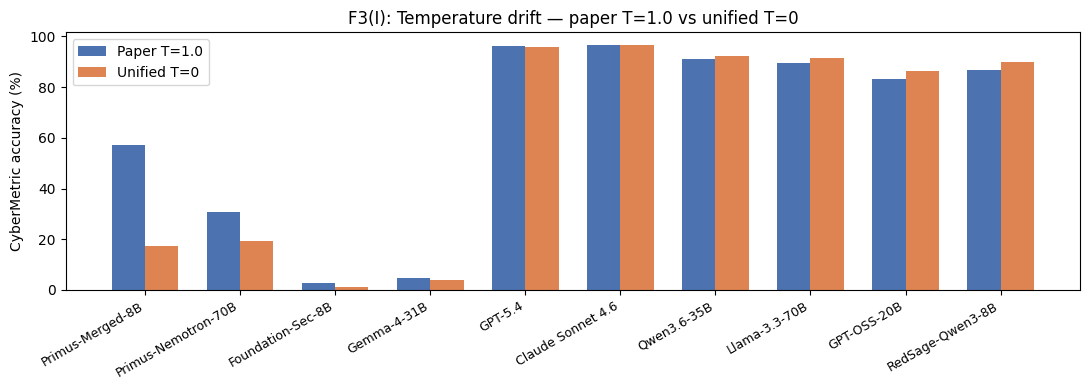

Model,Paper T=1.0 (%),Unified T=0 (%),Δ (pp)
Primus-Merged-8B,57.2%,17.2%,-40.0
Primus-Nemotron-70B,30.6%,19.2%,-11.4
Foundation-Sec-8B,2.8%,1.0%,-1.8
Gemma-4-31B,4.8%,4.0%,-0.8
GPT-5.4,96.2%,96.0%,-0.2
Claude Sonnet 4.6,96.6%,96.8%,+0.2
Qwen3.6-35B,91.0%,92.2%,+1.2
Llama-3.3-70B,89.6%,91.6%,+2.0
GPT-OSS-20B,83.4%,86.4%,+3.0
RedSage-Qwen3-8B,86.8%,89.8%,+3.0


In [4]:
from load_results import load_all_scores
import matplotlib.pyplot as plt, numpy as np

scores = load_all_scores(OUTPUTS_FINAL)
rows = []
for label, dir_name in PAPER_MODELS.items():
    p = scores.get(dir_name, {}).get('cybermetric_paper')
    u = scores.get(dir_name, {}).get('cybermetric')
    if p is not None and u is not None:
        rows.append({'Model': label,
                     'Paper T=1.0 (%)': round(p, 1),
                     'Unified T=0 (%)': round(u, 1),
                     'Δ (pp)':          round(u - p, 1)})

temp_df = pd.DataFrame(rows).sort_values('Δ (pp)').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(temp_df)); w = 0.35
ax.bar(x - w/2, temp_df['Paper T=1.0 (%)'].values, w, label='Paper T=1.0', color='#4C72B0')
ax.bar(x + w/2, temp_df['Unified T=0 (%)'].values, w, label='Unified T=0', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(temp_df['Model'].values, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('CyberMetric accuracy (%)')
ax.set_title('F3(I): Temperature drift — paper T=1.0 vs unified T=0')
ax.legend(); plt.tight_layout(); plt.show()
display(temp_df.style
        .hide(axis='index')
        .format({'Paper T=1.0 (%)': '{:.1f}%', 'Unified T=0 (%)': '{:.1f}%', 'Δ (pp)': '{:+.1f}'})
        .map(lambda v: 'color:red;font-weight:bold' if isinstance(v,(int,float)) and v <= -10 else '', subset=['Δ (pp)'])
        .set_caption('F3(I): Temperature drift — paper T=1.0 vs unified T=0. Red = gap ≥10pp.'))

### F2(A) + F3(E) — TAA metric drift and VSP direction mismatch

**F2(A):** CTI-Bench TAA awards Correct+Plausible via alias-graph BFS;
AthenaBench TAA uses binary correctness. Same models, opposite conventions.

**F3(E):** CTI-Bench VSP reports raw MAD (lower=better); AthenaBench VSP
normalises to a percentage (higher=better). Applied to same CVSS vectors.


In [5]:
from load_results import load_all_scores

scores = load_all_scores(OUTPUTS_FINAL)

# F2(A): TAA drift
taa_rows = []
for label, dir_name in PAPER_MODELS.items():
    cti = scores.get(dir_name, {}).get('cti_taa')
    ath = scores.get(dir_name, {}).get('taa')
    if cti is not None and ath is not None:
        taa_rows.append({'Model': label, 'CTI-TAA C+P (%)': round(cti,1),
                         'Athena-TAA (%)': round(ath,1), 'Gap (pp)': round(cti-ath,1)})

taa_df = pd.DataFrame(taa_rows).sort_values('Gap (pp)', ascending=False).reset_index(drop=True)
display(taa_df.style
        .hide(axis='index')
        .format({'CTI-TAA C+P (%)': '{:.1f}%', 'Athena-TAA (%)': '{:.1f}%', 'Gap (pp)': '{:+.1f}'})
        .map(lambda v: 'color:red;font-weight:bold' if isinstance(v,(int,float)) and v > 20 else '', subset=['Gap (pp)'])
        .set_caption('F2(A): TAA metric drift — CTI-Bench C+P partial credit vs AthenaBench binary. Red gap ≥20pp.'))

# F3(E): VSP direction mismatch
vsp_rows = []
for label, dir_name in PAPER_MODELS.items():
    cti = scores.get(dir_name, {}).get('vsp')
    ath = scores.get(dir_name, {}).get('athena_vsp')
    if cti is not None and ath is not None:
        vsp_rows.append({'Model': label, 'CTI-VSP MAD (↓)': round(cti,2),
                         'Athena-VSP % (↑)': round(ath,1)})

vsp_df = pd.DataFrame(vsp_rows).reset_index(drop=True)
display(vsp_df.style
        .hide(axis='index')
        .format({'CTI-VSP MAD (↓)': '{:.2f}', 'Athena-VSP % (↑)': '{:.1f}%'})
        .set_caption('F3(E): VSP metric-direction mismatch — CTI reports raw MAD (↓ better); Athena normalises to % (↑ better).'))

Model,CTI-TAA C+P (%),Athena-TAA (%),Gap (pp)
Llama-3.3-70B,70.0%,0.0%,+70.0
GPT-OSS-20B,64.0%,5.0%,+59.0
GPT-5.4,86.0%,33.0%,+53.0
Qwen3.6-35B,62.0%,14.0%,+48.0
Claude Sonnet 4.6,94.0%,47.0%,+47.0
Primus-Nemotron-70B,32.0%,12.0%,+20.0
Gemma-4-31B,26.0%,7.0%,+19.0
Foundation-Sec-8B,42.0%,25.0%,+17.0
Primus-Merged-8B,14.0%,8.0%,+6.0
RedSage-Qwen3-8B,20.0%,21.0%,-1.0


Model,CTI-VSP MAD (↓),Athena-VSP % (↑)
Claude Sonnet 4.6,0.80,88.6%
GPT-5.4,0.98,85.8%
Gemma-4-31B,1.38,85.4%
Qwen3.6-35B,1.38,83.1%
Llama-3.3-70B,1.59,74.4%
GPT-OSS-20B,1.27,78.8%
Primus-Nemotron-70B,1.43,73.6%
Primus-Merged-8B,1.67,53.3%
Foundation-Sec-8B,1.56,70.2%
RedSage-Qwen3-8B,1.15,73.5%
